In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df = pd.read_csv("Admission_Predict.csv")

df.columns = df.columns.str.strip()

df = df.drop_duplicates()

df = df.drop(columns=["Serial No."])

target = "Chance of Admit"

X = df.drop(columns=[target])
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (320, 7)
X_test : (80, 7)


In [ ]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

y_pred_linear = linear_model.predict(
    X_test
)

In [ ]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("===== LINEAR REGRESSION =====")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R2  :", r2_linear)

===== LINEAR REGRESSION =====
MAE : 0.047956733620911976
RMSE: 0.06794853476922813
R2  : 0.8212082591486993


In [ ]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(
        n_neighbors=5
    ))
])

knn_model.fit(
    X_train,
    y_train
)

y_pred_knn = knn_model.predict(
    X_test
)

In [ ]:
mae_knn = mean_absolute_error(
    y_test,
    y_pred_knn
)

rmse_knn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_knn
    )
)

r2_knn = r2_score(
    y_test,
    y_pred_knn
)

print("===== KNN REGRESSION =====")
print("MAE :", mae_knn)
print("RMSE:", rmse_knn)
print("R2  :", r2_knn)

===== KNN REGRESSION =====
MAE : 0.05422499999999999
RMSE: 0.07937285430170694
R2  : 0.7560329038328306


In [ ]:
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(
        kernel="rbf",
        C=1.0,
        epsilon=0.1
    ))
])

svr_model.fit(
    X_train,
    y_train
)

y_pred_svr = svr_model.predict(
    X_test
)

In [ ]:
mae_svr = mean_absolute_error(
    y_test,
    y_pred_svr
)

rmse_svr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_svr
    )
)

r2_svr = r2_score(
    y_test,
    y_pred_svr
)

print("===== SVR =====")
print("MAE :", mae_svr)
print("RMSE:", rmse_svr)
print("R2  :", r2_svr)

===== SVR =====
MAE : 0.06480783431388584
RMSE: 0.07876070749343232
R2  : 0.7597814848647667


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test
)

In [ ]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("===== RANDOM FOREST =====")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

===== RANDOM FOREST =====
MAE : 0.05001750000000001
RMSE: 0.0705911135519196
R2  : 0.8070310976919512


In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

y_pred_gb = gb_model.predict(
    X_test
)

In [ ]:
mae_gb = mean_absolute_error(
    y_test,
    y_pred_gb
)

rmse_gb = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gb
    )
)

r2_gb = r2_score(
    y_test,
    y_pred_gb
)

print("===== GRADIENT BOOSTING =====")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R2  :", r2_gb)

===== GRADIENT BOOSTING =====
MAE : 0.047612784527643094
RMSE: 0.07024301251743102
R2  : 0.8089295534375465


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN Regression",
        "SVR",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mae_linear,
        mae_knn,
        mae_svr,
        mae_rf,
        mae_gb
    ],

    "RMSE": [
        rmse_linear,
        rmse_knn,
        rmse_svr,
        rmse_rf,
        rmse_gb
    ],

    "R2": [
        r2_linear,
        r2_knn,
        r2_svr,
        r2_rf,
        r2_gb
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.047957,0.067949,0.821208
1,KNN Regression,0.054225,0.079373,0.756033
2,SVR,0.064808,0.078761,0.759781
3,Random Forest,0.050018,0.070591,0.807031
4,Gradient Boosting,0.047613,0.070243,0.808930


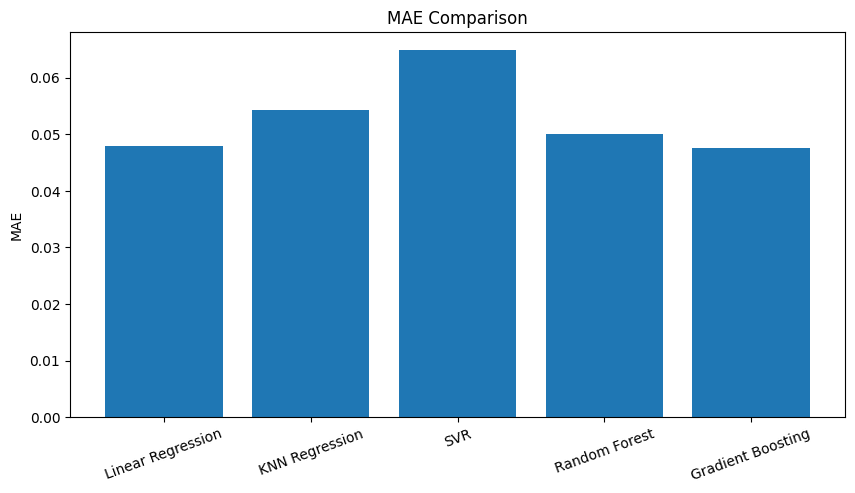

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.xticks(rotation=20)
plt.ylabel("MAE")
plt.title("MAE Comparison")

plt.show()

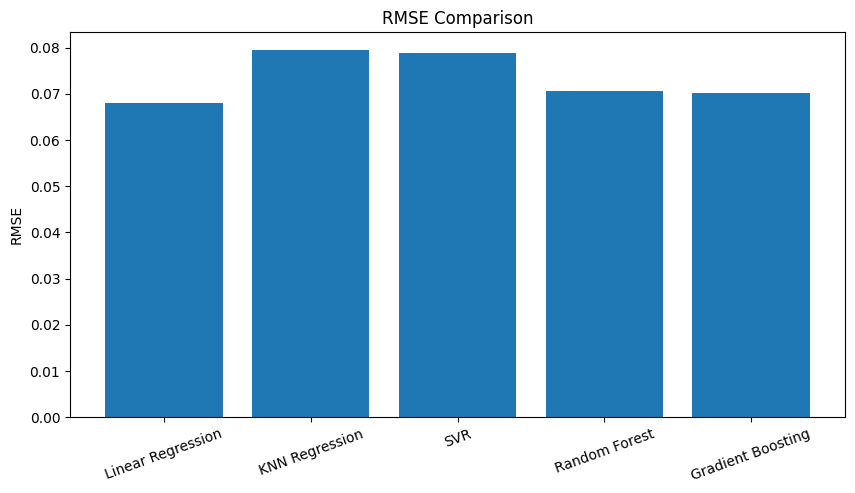

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.xticks(rotation=20)
plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.show()

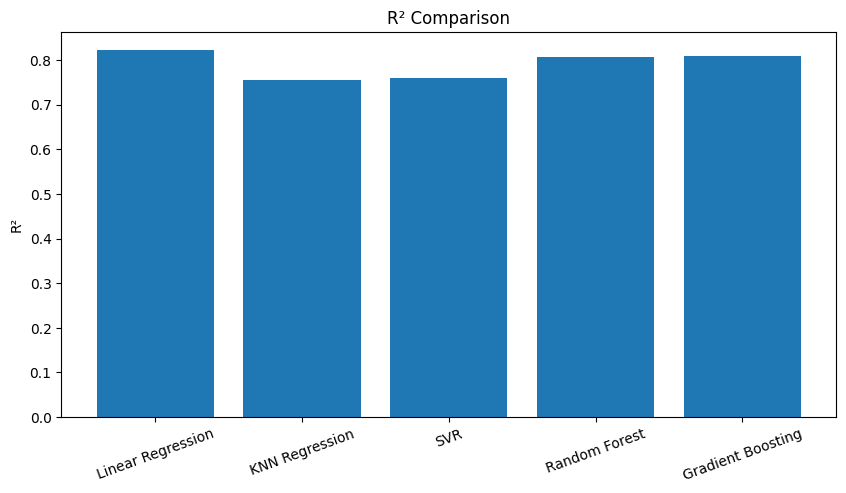

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["R2"]
)

plt.xticks(rotation=20)
plt.ylabel("R²")
plt.title("R² Comparison")

plt.show()